In [17]:







import os, time, copy, random
from typing import Dict, Any, List, Tuple, Optional

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR, LambdaLR
from torch.utils.data import Dataset, DataLoader, random_split

import torchvision
from torchvision import transforms
import timm

import torchquantum as tq
import torchquantum.functional as tqf

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc, precision_recall_fscore_support,
)
from sklearn.preprocessing import label_binarize


SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

TRAIN_DIR = "/home/jovyan/ssh-test-datavol-1/dataset/dataset/train"
VAL_DIR   = "/home/jovyan/ssh-test-datavol-1/dataset/dataset/val"

CKPT_ROOT    = "./checkpoints"
STAGE1_DIR   = os.path.join(CKPT_ROOT, "stage1")
STAGE2_DIR   = os.path.join(CKPT_ROOT, "stage2")
BASELINE_DIR = os.path.join(CKPT_ROOT, "baseline")
for d in (CKPT_ROOT, STAGE1_DIR, STAGE2_DIR, BASELINE_DIR):
    os.makedirs(d, exist_ok=True)


def _safe_name(s: str) -> str:
    return s.replace("/", "__").replace(".", "_").replace(":", "_")


CFG: Dict[str, Any] = {
    "backbone":    "convnext_tiny",
    "pretrained":  True,

    "n_qubits":    8,
    "n_qlayers":   1,
    "n_classes":   3,
    "class_names": ["no", "sphere", "vort"],

    "input_size":   150,
    "resize_to":    224,
    "imagenet_mean": [0.485, 0.456, 0.406],
    "imagenet_std":  [0.229, 0.224, 0.225],

    "batch_size":  256,
    "test_split":  0.10,

    "class_weights":    [1.0, 2.5, 2.0],
    "grad_clip":        1.0,
    "warmup_epochs":    8,
    "use_augmentation": True,


    "stage1_epochs":      40,
    "stage1_wd":          5e-4,
    "stage1_lr_backbone": 5e-5,
    "stage1_lr_bridge":   5e-4,
    "stage1_lr_quantum":  5e-3,


    "stage2_epochs": 60,
    "stage2_wd":     1e-4,
    "lr_backbone":   3e-5,
    "lr_bridge":     2e-4,
    "lr_quantum":    5e-3,

    "seed": SEED,
}

_bb = _safe_name(CFG["backbone"])
CFG["stage1_ckpt"]   = os.path.join(STAGE1_DIR,   f"{_bb}.pth")
CFG["stage2_ckpt"]   = os.path.join(STAGE2_DIR,   f"{_bb}.pth")
CFG["baseline_ckpt"] = os.path.join(BASELINE_DIR, f"{_bb}.pth")

print(f"PyTorch {torch.__version__} | TorchQuantum {tq.__version__} | timm {timm.__version__}")
print(f"Device: {device} | CUDA: {torch.cuda.is_available()}")
print(f"Backbone: {CFG['backbone']}  pretrained={CFG['pretrained']}")
print(f"Stage 1 LRs: backbone={CFG['stage1_lr_backbone']} bridge={CFG['stage1_lr_bridge']} quantum={CFG['stage1_lr_quantum']}")
print(f"Stage 2 LRs: backbone={CFG['lr_backbone']} bridge={CFG['lr_bridge']} quantum={CFG['lr_quantum']}")
print(f"class_weights={CFG['class_weights']}, grad_clip={CFG['grad_clip']}, "
      f"warmup={CFG['warmup_epochs']}, use_augmentation={CFG['use_augmentation']}")
print(f"\nCheckpoint layout:")
print(f"  stage1   -> {CFG['stage1_ckpt']}")
print(f"  stage2   -> {CFG['stage2_ckpt']}")
print(f"  baseline -> {CFG['baseline_ckpt']}")

PyTorch 2.5.1+cu124 | TorchQuantum 0.1.8 | timm 1.0.26
Device: cuda:0 | CUDA: True
Backbone: convnext_tiny  pretrained=True
Stage 1 LRs: backbone=5e-05 bridge=0.0005 quantum=0.005
Stage 2 LRs: backbone=3e-05 bridge=0.0002 quantum=0.005
class_weights=[1.0, 2.5, 2.0], grad_clip=1.0, warmup=8, use_augmentation=True

Checkpoint layout:
  stage1   -> ./checkpoints/stage1/convnext_tiny.pth
  stage2   -> ./checkpoints/stage2/convnext_tiny.pth
  baseline -> ./checkpoints/baseline/convnext_tiny.pth


In [2]:


class GPUTensorDataset:
    def __init__(self, cache: torch.Tensor, labels: torch.Tensor, classes: List[str]):
        self.cache  = cache
        self.labels = labels
        self.classes = classes
    def __len__(self) -> int:
        return self.cache.size(0)


class GPULoader:
    def __init__(self, dataset: GPUTensorDataset, batch_size: int,
                 shuffle: bool = False, seed: int = 42):
        self.dataset = dataset
        self.bs = batch_size
        self.shuffle = shuffle
        self.seed = seed
        self._epoch = 0

    def __len__(self) -> int:
        return (len(self.dataset) + self.bs - 1) // self.bs

    def __iter__(self):
        n   = len(self.dataset)
        dev = self.dataset.cache.device
        if self.shuffle:
            g = torch.Generator(); g.manual_seed(self.seed + self._epoch)
            perm = torch.randperm(n, generator=g).to(dev)
        else:
            perm = torch.arange(n, device=dev)
        self._epoch += 1
        cache, labels = self.dataset.cache, self.dataset.labels
        for i in range(0, n, self.bs):
            idx = perm[i:i + self.bs]
            yield cache.index_select(0, idx).float(), labels.index_select(0, idx)


def build_gpu_cache(root_dir, resize_to, mean, std, device,
                    dtype: torch.dtype = torch.float32, chunk: int = 256):
    classes = sorted([d for d in os.listdir(root_dir)
                      if os.path.isdir(os.path.join(root_dir, d))])
    class_to_idx = {c: i for i, c in enumerate(classes)}
    files: List[Tuple[str, int]] = []
    for c in classes:
        cdir = os.path.join(root_dir, c)
        for f in os.listdir(cdir):
            if f.endswith(".npy"):
                files.append((os.path.join(cdir, f), class_to_idx[c]))

    N = len(files)
    cache  = torch.empty((N, 3, resize_to, resize_to), dtype=dtype,        device=device)
    labels = torch.empty((N,),                          dtype=torch.long, device=device)
    m = torch.tensor(mean, device=device, dtype=torch.float32).view(1, 3, 1, 1)
    s = torch.tensor(std,  device=device, dtype=torch.float32).view(1, 3, 1, 1)

    print(f"Caching {N} samples from {root_dir} -> GPU 3x{resize_to}x{resize_to} {dtype}")
    for cs in tqdm(range(0, N, chunk), desc="cache build"):
        ce = min(cs + chunk, N)
        cpu_imgs, cpu_lbls = [], []
        for fp, lbl in files[cs:ce]:
            arr = np.load(fp)
            if arr.ndim == 2:
                arr = arr[np.newaxis, :, :]
            elif arr.ndim == 3 and arr.shape[0] not in (1, 3):
                arr = arr.transpose(2, 0, 1)
            if arr.max() > 1.0:
                arr = arr / 255.0
            t = torch.from_numpy(np.ascontiguousarray(arr)).float()
            if t.shape[0] == 1:
                t = t.repeat(3, 1, 1)
            cpu_imgs.append(t)
            cpu_lbls.append(lbl)
        batch = torch.stack(cpu_imgs, dim=0).to(device, non_blocking=True)
        batch = F.interpolate(batch, size=(resize_to, resize_to),
                              mode="bilinear", align_corners=False)
        batch = (batch - m) / s
        cache[cs:ce]  = batch.to(dtype)
        labels[cs:ce] = torch.tensor(cpu_lbls, dtype=torch.long, device=device)
    return GPUTensorDataset(cache, labels, classes)


class GPUAugment(nn.Module):
    """Per-sample h/v flips + per-batch 90-deg rotation. All label-preserving."""
    def __init__(self, p_hflip: float = 0.5, p_vflip: float = 0.5, p_rot90: float = 0.75):
        super().__init__()
        self.p_hflip = p_hflip
        self.p_vflip = p_vflip
        self.p_rot90 = p_rot90

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B = x.shape[0]; dev = x.device
        m = (torch.rand(B, device=dev) < self.p_hflip).view(B, 1, 1, 1)
        x = torch.where(m, x.flip(-1), x)
        m = (torch.rand(B, device=dev) < self.p_vflip).view(B, 1, 1, 1)
        x = torch.where(m, x.flip(-2), x)
        if torch.rand(1, device=dev).item() < self.p_rot90:
            k = int(torch.randint(1, 4, (1,)).item())
            x = torch.rot90(x, k, dims=[-2, -1])
        return x



CACHE_DTYPE = torch.float32
t0 = time.time()
train_set = build_gpu_cache(TRAIN_DIR, CFG["resize_to"], CFG["imagenet_mean"], CFG["imagenet_std"],
                            device, dtype=CACHE_DTYPE)
val_full  = build_gpu_cache(VAL_DIR, CFG["resize_to"], CFG["imagenet_mean"], CFG["imagenet_std"],
                            device, dtype=CACHE_DTYPE)
print(f"Cache build took {time.time()-t0:.1f}s | "
      f"GPU mem allocated {torch.cuda.memory_allocated()/1e9:.2f} GB")

g = torch.Generator().manual_seed(CFG["seed"])
n_total = len(val_full); n_test = int(n_total * CFG["test_split"])
perm = torch.randperm(n_total, generator=g)
val_idx, test_idx = perm[n_test:].to(device), perm[:n_test].to(device)
val_set  = GPUTensorDataset(val_full.cache.index_select(0, val_idx),
                            val_full.labels.index_select(0, val_idx), val_full.classes)
test_set = GPUTensorDataset(val_full.cache.index_select(0, test_idx),
                            val_full.labels.index_select(0, test_idx), val_full.classes)
del val_full; torch.cuda.empty_cache()

train_loader = GPULoader(train_set, batch_size=CFG["batch_size"], shuffle=True,  seed=CFG["seed"])
val_loader   = GPULoader(val_set,   batch_size=CFG["batch_size"], shuffle=False)
test_loader  = GPULoader(test_set,  batch_size=CFG["batch_size"], shuffle=False)

augmenter = GPUAugment().to(device) if CFG["use_augmentation"] else None
print(f"Augmentation: {'ON' if augmenter is not None else 'OFF'}")

CLASS_NAMES = train_set.classes
assert CLASS_NAMES == CFG["class_names"], f"class mismatch: {CLASS_NAMES}"
print(f"Sizes: train={len(train_set)} val={len(val_set)} test={len(test_set)}")

import collections
counts = collections.Counter(train_set.labels.cpu().tolist())
print("Class counts (train):", {CLASS_NAMES[k]: v for k, v in sorted(counts.items())})

Caching 30000 samples from /home/jovyan/ssh-test-datavol-1/dataset/dataset/train -> GPU 3x224x224 torch.float32


cache build:   0%|          | 0/118 [00:00<?, ?it/s]

Caching 7500 samples from /home/jovyan/ssh-test-datavol-1/dataset/dataset/val -> GPU 3x224x224 torch.float32


cache build:   0%|          | 0/30 [00:00<?, ?it/s]

Cache build took 650.1s | GPU mem allocated 22.58 GB
Augmentation: ON
Sizes: train=30000 val=6750 test=750
Class counts (train): {'no': 10000, 'sphere': 10000, 'vort': 10000}


In [18]:


class VQC(tq.QuantumModule):
    def __init__(self, n_wires: int = 8, n_qlayers: int = 1):
        super().__init__()
        self.n_wires = n_wires
        self.n_qlayers = n_qlayers
        self.encoder = tq.GeneralEncoder([
            {"input_idx": [i], "func": "ry", "wires": [i]} for i in range(n_wires)
        ])
        self.params_rx_dct = tq.QuantumModuleDict()
        self.params_ry_dct = tq.QuantumModuleDict()
        self.params_rz_dct = tq.QuantumModuleDict()
        for k in range(n_qlayers):
            for i in range(n_wires):
                key = str(i + k * n_wires)
                self.params_rx_dct[key] = tq.RX(has_params=True, trainable=True)
                self.params_ry_dct[key] = tq.RY(has_params=True, trainable=True)
                self.params_rz_dct[key] = tq.RZ(has_params=True, trainable=True)
        self.measure = tq.MeasureAll(tq.PauliZ)

    @tq.static_support
    def forward(self, x: torch.Tensor, q_device: tq.QuantumDevice):
        self.q_device = q_device
        self.encoder(self.q_device, x)
        for k in range(self.n_qlayers):
            for i in range(self.n_wires):
                key = str(i + k * self.n_wires)
                self.params_rx_dct[key](self.q_device, wires=i)
                self.params_ry_dct[key](self.q_device, wires=i)
                self.params_rz_dct[key](self.q_device, wires=i)
            for i in range(self.n_wires):
                tgt = 0 if i == self.n_wires - 1 else i + 1
                tqf.cnot(self.q_device, wires=[i, tgt],
                         static=self.static_mode, parent_graph=self.graph)
        return self.measure(self.q_device)

In [19]:


def _is_modern_arch(name: str) -> bool:
    """
    Backbones that internally use LayerNorm/GELU (ConvNeXt, ViT family, Swin, etc.).
    For these we use LayerNorm in the bridge MLP — avoids BN running-stats drift
    when the trunk produces high-variance features under heavy augmentation.
    """
    return any(name.lower().startswith(p) for p in (
        "convnext", "vit", "deit", "swin", "beit", "eva", "mobilevit", "coatnet",
    ))


def _make_bridge(in_dim: int, n_qubits: int, dropout: float = 0.2,
                 norm: str = "bn") -> nn.Sequential:
    """
    Bridge MLP:  in_dim -> 256 -> 128 -> 64 -> 32 -> n_qubits
    Norm + ReLU + Dropout(decreasing) BETWEEN layers; no activation on the final layer.
    `norm`: 'bn' (BatchNorm1d) for ResNet-style backbones,
            'ln' (LayerNorm)   for ConvNeXt / ViT / Swin / DeiT etc.
    """
    dims = [in_dim, 256, 128, 64, 32, n_qubits]
    layers: List[nn.Module] = []
    for i in range(len(dims) - 2):
        d = dropout * (1.0 - 0.2 * i)
        norm_layer = (nn.LayerNorm(dims[i + 1])
                      if norm.lower() == "ln"
                      else nn.BatchNorm1d(dims[i + 1]))
        layers += [
            nn.Linear(dims[i], dims[i + 1]),
            norm_layer,
            nn.ReLU(inplace=True),
            nn.Dropout(d),
        ]
    layers.append(nn.Linear(dims[-2], dims[-1]))
    seq = nn.Sequential(*layers)

    for m in seq.modules():
        if isinstance(m, nn.Linear):
            nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
            if m.bias is not None:
                nn.init.zeros_(m.bias)
    return seq


class TimmFrontEnd(nn.Module):
    """timm trunk -> bridge MLP -> n_qubits, with the right norm for the trunk family."""
    def __init__(self, name: str, n_qubits: int, pretrained: bool = True):
        super().__init__()
        self.backbone = timm.create_model(name, pretrained=pretrained, num_classes=0)
        self.feat_dim = self.backbone.num_features
        self.n_qubits = n_qubits
        norm = "ln" if _is_modern_arch(name) else "bn"
        self.bridge_norm = norm
        self.bridge = _make_bridge(in_dim=self.feat_dim, n_qubits=n_qubits,
                                   dropout=0.2, norm=norm)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.bridge(self.backbone(x))


def get_frontend(name: str, n_qubits: int, pretrained: bool = True) -> nn.Module:
    return TimmFrontEnd(name, n_qubits=n_qubits, pretrained=pretrained)



_fe = get_frontend(CFG["backbone"], n_qubits=CFG["n_qubits"], pretrained=CFG["pretrained"]).to(device)
_xb = torch.randn(2, 3, CFG["resize_to"], CFG["resize_to"], device=device)
_yb = _fe(_xb)
data_cfg = timm.data.resolve_model_data_config(_fe.backbone)
print(f"backbone        : {CFG['backbone']}")
print(f"bridge norm     : {_fe.bridge_norm.upper()}  "
      f"({'LayerNorm — ConvNeXt / ViT family' if _fe.bridge_norm == 'ln' else 'BatchNorm1d — classic CNN'})")
print(f"feat_dim        : {_fe.feat_dim} -> n_qubits={_fe.n_qubits}")
print(f"output shape    : {tuple(_yb.shape)} (expected (2, {CFG['n_qubits']}))")
print(f"timm cfg        : input={data_cfg.get('input_size')}, "
      f"mean={data_cfg.get('mean')}, std={data_cfg.get('std')}")
print(f"trainable params: {sum(p.numel() for p in _fe.parameters() if p.requires_grad):,}")
del _fe, _xb, _yb

backbone        : convnext_tiny
bridge norm     : LN  (LayerNorm — ConvNeXt / ViT family)
feat_dim        : 768 -> n_qubits=8
output shape    : (2, 8) (expected (2, 8))
timm cfg        : input=(3, 224, 224), mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)
trainable params: 28,061,448


In [20]:


class Stage1Model(nn.Module):
    """frontend -> sigmoid*pi/2 -> VQC -> Linear(n_qubits, n_classes) -> log_softmax"""
    def __init__(self, frontend: nn.Module, n_qubits: int, n_qlayers: int, n_classes: int):
        super().__init__()
        self.frontend = frontend
        self.n_qubits = n_qubits
        self.vqc  = VQC(n_wires=n_qubits, n_qlayers=n_qlayers)
        self.head = nn.Linear(n_qubits, n_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        bsz = x.shape[0]
        qdev = tq.QuantumDevice(n_wires=self.n_qubits, bsz=bsz, device=x.device)
        pre_out = self.frontend(x)
        q_in = torch.sigmoid(pre_out) * (np.pi / 2.0)
        q_out = self.vqc(q_in, qdev)
        return F.log_softmax(self.head(q_out), dim=1)


def build_stage1_model(cfg: Dict[str, Any]) -> Stage1Model:
    fe = get_frontend(cfg["backbone"], cfg["n_qubits"], pretrained=cfg["pretrained"])
    return Stage1Model(fe, n_qubits=cfg["n_qubits"],
                       n_qlayers=cfg["n_qlayers"], n_classes=cfg["n_classes"])


_m = build_stage1_model(CFG).to(device)
_xb = torch.randn(2, 3, CFG["resize_to"], CFG["resize_to"], device=device)
_yb = _m(_xb)
print(f"Stage1Model out shape: {tuple(_yb.shape)} (expected (2, {CFG['n_classes']}))")
print(f"Stage1Model params: {sum(p.numel() for p in _m.parameters()):,}")
print(f"  backbone : {sum(p.numel() for p in _m.frontend.backbone.parameters()):,}")
print(f"  bridge   : {sum(p.numel() for p in _m.frontend.bridge.parameters()):,}")
print(f"  vqc      : {sum(p.numel() for p in _m.vqc.parameters()):,}")
print(f"  head     : {sum(p.numel() for p in _m.head.parameters()):,}")
del _m, _xb, _yb

Stage1Model out shape: (2, 3) (expected (2, 3))
Stage1Model params: 28,061,499
  backbone : 27,820,128
  bridge   : 241,320
  vqc      : 24
  head     : 27


In [21]:


def get_stage1_param_groups(model: Stage1Model, cfg: Dict[str, Any]) -> List[Dict[str, Any]]:
    return [
        {"params": list(model.frontend.backbone.parameters()),
         "lr": cfg["stage1_lr_backbone"], "name": "backbone"},
        {"params": list(model.frontend.bridge.parameters()),
         "lr": cfg["stage1_lr_bridge"],   "name": "bridge"},
        {"params": list(model.vqc.parameters()) + list(model.head.parameters()),
         "lr": cfg["stage1_lr_quantum"],  "name": "quantum"},
    ]


def warmup_cosine_factor(epoch: int, warmup: int, total: int) -> float:
    if warmup > 0 and epoch < warmup:
        return (epoch + 1) / warmup
    progress = (epoch - warmup) / max(1, total - warmup)
    return 0.5 * (1.0 + np.cos(np.pi * progress))


def run_stage1(cfg, train_loader, val_loader, augmenter: Optional[nn.Module] = None):
    torch.manual_seed(cfg["seed"])
    model = build_stage1_model(cfg).to(device)

    cw = cfg.get("class_weights")
    if cw is not None and any(w != 1.0 for w in cw):
        cw_t = torch.tensor(cw, dtype=torch.float32, device=device)
        criterion = nn.NLLLoss(weight=cw_t)
        print(f"[S1] using class weights {cw}")
    else:
        criterion = nn.NLLLoss()

    optimizer = optim.Adam(get_stage1_param_groups(model, cfg), weight_decay=cfg["stage1_wd"])
    scheduler = LambdaLR(
        optimizer,
        lr_lambda=lambda e: warmup_cosine_factor(e, cfg["warmup_epochs"], cfg["stage1_epochs"]),
    )

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_acc, best_state = -1.0, None
    print(f"[S1] paper-faithful: frontend + VQC + Linear({cfg['n_qubits']}->{cfg['n_classes']})")
    print(f"[S1] augmentation: {'ON' if augmenter is not None else 'OFF'}")
    print(f"[S1] trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

    for epoch in range(cfg["stage1_epochs"]):
        model.train()
        tr_loss = tr_correct = tr_total = 0
        pbar = tqdm(train_loader, desc=f"[S1] ep {epoch+1}/{cfg['stage1_epochs']}", leave=False)
        for xb, yb in pbar:
            xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
            if augmenter is not None and model.training:
                xb = augmenter(xb)
            optimizer.zero_grad(set_to_none=True)
            logp = model(xb)
            loss = criterion(logp, yb)
            loss.backward()
            if cfg.get("grad_clip"):
                torch.nn.utils.clip_grad_norm_(model.parameters(), cfg["grad_clip"])
            optimizer.step()
            tr_loss    += loss.item() * xb.size(0)
            tr_correct += (logp.argmax(1) == yb).sum().item()
            tr_total   += xb.size(0)
            pbar.set_postfix(loss=f"{loss.item():.4f}")
        train_loss, train_acc = tr_loss / tr_total, tr_correct / tr_total

        model.eval()
        v_loss = v_correct = v_total = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
                logp = model(xb)
                v_loss    += criterion(logp, yb).item() * xb.size(0)
                v_correct += (logp.argmax(1) == yb).sum().item()
                v_total   += xb.size(0)
        val_loss, val_acc = v_loss / v_total, v_correct / v_total

        for k, v in zip(["train_loss", "train_acc", "val_loss", "val_acc"],
                        [train_loss, train_acc, val_loss, val_acc]):
            history[k].append(v)

        is_best = val_acc > best_val_acc
        if is_best:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())
            torch.save(best_state, cfg["stage1_ckpt"])

        scheduler.step()
        lrs = " ".join(f"{g['name']}={g['lr']:.1e}" for g in optimizer.param_groups)
        print(f"[S1] ep {epoch+1:02d}/{cfg['stage1_epochs']} | {lrs} | "
              f"train loss={train_loss:.4f} acc={train_acc:.4f} | "
              f"val loss={val_loss:.4f} acc={val_acc:.4f} {'*' if is_best else ''}")

    if best_state is not None:
        model.load_state_dict(best_state)
    print(f"\n[S1] Best val acc: {best_val_acc:.4f}")
    print(f"[S1] Saved best ckpt: {cfg['stage1_ckpt']}")
    return model, history


t0 = time.time()
stage1_model, stage1_history = run_stage1(CFG, train_loader, val_loader, augmenter=augmenter)
print(f"[S1] total time: {(time.time()-t0)/60:.1f} min")

[S1] using class weights [1.0, 2.5, 2.0]
[S1] paper-faithful: frontend + VQC + Linear(8->3)
[S1] augmentation: ON
[S1] trainable params: 28,061,499


[S1] ep 1/40:   0%|          | 0/118 [00:00<?, ?it/s]

[S1] ep 01/40 | backbone=1.3e-05 bridge=1.3e-04 quantum=1.3e-03 | train loss=1.0707 acc=0.3371 | val loss=1.0457 acc=0.3335 *


[S1] ep 2/40:   0%|          | 0/118 [00:00<?, ?it/s]

[S1] ep 02/40 | backbone=1.9e-05 bridge=1.9e-04 quantum=1.9e-03 | train loss=1.0369 acc=0.3335 | val loss=1.0231 acc=0.3363 *


...

[S1] ep 38/40 | backbone=4.8e-07 bridge=4.8e-06 quantum=4.8e-05 | train loss=0.2475 acc=0.9387 | val loss=0.2615 acc=0.9279 


[S1] ep 39/40:   0%|          | 0/118 [00:00<?, ?it/s]

[S1] ep 39/40 | backbone=1.2e-07 bridge=1.2e-06 quantum=1.2e-05 | train loss=0.2503 acc=0.9380 | val loss=0.2552 acc=0.9357 *


[S1] ep 40/40:   0%|          | 0/118 [00:00<?, ?it/s]

[S1] ep 40/40 | backbone=0.0e+00 bridge=0.0e+00 quantum=0.0e+00 | train loss=0.2477 acc=0.9378 | val loss=0.2550 acc=0.9354 

[S1] Best val acc: 0.9357
[S1] Saved best ckpt: ./checkpoints/stage1/convnext_tiny.pth
[S1] total time: 30.0 min


eval:   0%|          | 0/3 [00:00<?, ?it/s]


=== Stage 1 (paper-faithful: frontend+VQC+head trained from scratch) ===
Test accuracy: 0.9320
Macro ROC-AUC: 0.9850
              precision    recall  f1-score   support

          no     0.9053    0.9607    0.9322       229
      sphere     0.9087    0.9197    0.9142       249
        vort     0.9804    0.9191    0.9488       272

    accuracy                         0.9320       750
   macro avg     0.9315    0.9332    0.9317       750
weighted avg     0.9337    0.9320    0.9322       750



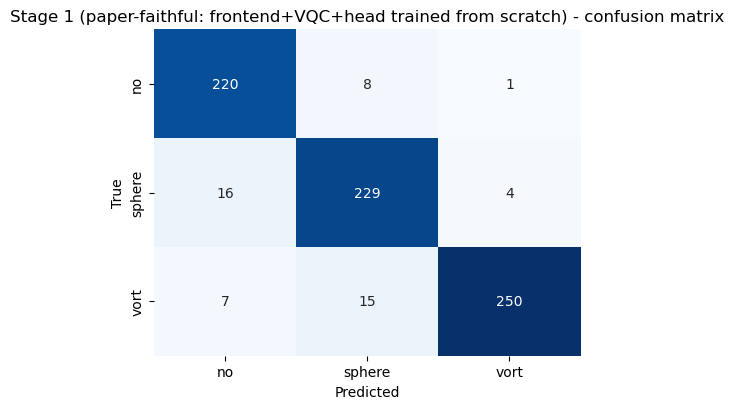

In [22]:


@torch.no_grad()
def collect_predictions(model: nn.Module, loader, dev):
    model.eval()
    all_logp, all_y = [], []
    for xb, yb in tqdm(loader, desc="eval", leave=False):
        xb = xb.to(dev, non_blocking=True)
        all_logp.append(model(xb).detach().cpu())
        all_y.append(yb.detach().cpu())
    logp  = torch.cat(all_logp, dim=0).numpy()
    y     = torch.cat(all_y,    dim=0).numpy()
    probs = np.exp(logp)
    return probs, probs.argmax(axis=1), y


def plot_confusion(cm, class_names, title):
    fig, ax = plt.subplots(figsize=(5.0, 4.2))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, ax=ax, cbar=False)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title(title)
    plt.tight_layout(); plt.show()


def evaluate_classifier(model, loader, class_names, tag: str):
    probs, preds, y = collect_predictions(model, loader, device)
    acc = accuracy_score(y, preds)
    y_bin = label_binarize(y, classes=list(range(len(class_names))))
    macro_auc = roc_auc_score(y_bin, probs, average="macro", multi_class="ovr")
    cm = confusion_matrix(y, preds)
    print(f"\n=== {tag} ===")
    print(f"Test accuracy: {acc:.4f}")
    print(f"Macro ROC-AUC: {macro_auc:.4f}")
    print(classification_report(y, preds, target_names=class_names, digits=4))
    plot_confusion(cm, class_names, title=f"{tag} - confusion matrix")
    return {"tag": tag, "accuracy": acc, "macro_auc": macro_auc,
            "probs": probs, "preds": preds, "targets": y}


stage1_results = evaluate_classifier(
    stage1_model, test_loader, CLASS_NAMES,
    tag="Stage 1 (paper-faithful: frontend+VQC+head trained from scratch)")

In [23]:


class Stage2Model(nn.Module):
    """frontend (loaded) -> sigmoid*pi/2 -> VQC (fresh) -> Linear (fresh) -> log_softmax"""
    def __init__(self, frontend: nn.Module, n_qubits: int, n_qlayers: int, n_classes: int):
        super().__init__()
        self.frontend = frontend
        self.n_qubits = n_qubits
        self.vqc  = VQC(n_wires=n_qubits, n_qlayers=n_qlayers)
        self.head = nn.Linear(n_qubits, n_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        bsz = x.shape[0]
        qdev = tq.QuantumDevice(n_wires=self.n_qubits, bsz=bsz, device=x.device)
        pre_out = self.frontend(x)
        q_in = torch.sigmoid(pre_out) * (np.pi / 2.0)
        q_out = self.vqc(q_in, qdev)
        return F.log_softmax(self.head(q_out), dim=1)


def build_stage2_model(cfg) -> Stage2Model:
    fe = get_frontend(cfg["backbone"], cfg["n_qubits"], pretrained=cfg["pretrained"])
    return Stage2Model(fe, n_qubits=cfg["n_qubits"],
                       n_qlayers=cfg["n_qlayers"], n_classes=cfg["n_classes"])

In [24]:


def load_frontend_from_stage1(stage2_model: Stage2Model,
                              stage1_ckpt_path: str,
                              strict: bool = True) -> Stage2Model:
    saved = torch.load(stage1_ckpt_path, map_location="cpu", weights_only=True)
    fe_state = stage2_model.frontend.state_dict()
    fe_from_saved = {
        k[len("frontend."):]: v for k, v in saved.items() if k.startswith("frontend.")
    }
    n_loaded = 0
    for k in fe_state.keys():
        if k in fe_from_saved and fe_from_saved[k].shape == fe_state[k].shape:
            fe_state[k] = fe_from_saved[k]
            n_loaded += 1
    result = stage2_model.frontend.load_state_dict(fe_state, strict=strict)
    n_skipped = sum(1 for k in saved if not k.startswith("frontend."))
    print(f"[FE-load] frontend keys loaded: {n_loaded}/{len(fe_state)}")
    print(f"[FE-load] non-frontend keys (vqc.* / head.*) skipped: {n_skipped}")
    if getattr(result, "missing_keys", []):
        print(f"  missing:    {result.missing_keys}")
    if getattr(result, "unexpected_keys", []):
        print(f"  unexpected: {result.unexpected_keys}")
    return stage2_model

In [25]:


def get_stage2_param_groups(model: Stage2Model, cfg: Dict[str, Any]) -> List[Dict[str, Any]]:
    return [
        {"params": list(model.frontend.backbone.parameters()),
         "lr": cfg["lr_backbone"], "name": "backbone"},
        {"params": list(model.frontend.bridge.parameters()),
         "lr": cfg["lr_bridge"],   "name": "bridge"},
        {"params": list(model.vqc.parameters()) + list(model.head.parameters()),
         "lr": cfg["lr_quantum"],  "name": "quantum"},
    ]


def run_stage2(cfg, train_loader, val_loader, load_stage1: bool,
               ckpt_save_path: str, run_tag: str,
               augmenter: Optional[nn.Module] = None):
    torch.manual_seed(cfg["seed"])
    model = build_stage2_model(cfg).to(device)
    if load_stage1:
        model = load_frontend_from_stage1(model, cfg["stage1_ckpt"], strict=True)
    else:
        print(f"[{run_tag}] Skipping Stage-1 weights -> ImageNet-only.")

    cw = cfg.get("class_weights")
    if cw is not None and any(w != 1.0 for w in cw):
        cw_t = torch.tensor(cw, dtype=torch.float32, device=device)
        criterion = nn.NLLLoss(weight=cw_t)
    else:
        criterion = nn.NLLLoss()

    optimizer = optim.Adam(get_stage2_param_groups(model, cfg), weight_decay=cfg["stage2_wd"])
    scheduler = LambdaLR(
        optimizer,
        lr_lambda=lambda e: warmup_cosine_factor(e, cfg["warmup_epochs"], cfg["stage2_epochs"]),
    )

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_acc, best_state = -1.0, None
    print(f"[{run_tag}] augmentation: {'ON' if augmenter is not None else 'OFF'}")

    for epoch in range(cfg["stage2_epochs"]):
        model.train()
        tr_loss = tr_correct = tr_total = 0
        pbar = tqdm(train_loader, desc=f"[{run_tag}] ep {epoch+1}/{cfg['stage2_epochs']}", leave=False)
        for xb, yb in pbar:
            xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
            if augmenter is not None and model.training:
                xb = augmenter(xb)
            optimizer.zero_grad(set_to_none=True)
            logp = model(xb)
            loss = criterion(logp, yb)
            loss.backward()
            if cfg.get("grad_clip"):
                torch.nn.utils.clip_grad_norm_(model.parameters(), cfg["grad_clip"])
            optimizer.step()
            tr_loss    += loss.item() * xb.size(0)
            tr_correct += (logp.argmax(1) == yb).sum().item()
            tr_total   += xb.size(0)
            pbar.set_postfix(loss=f"{loss.item():.4f}")
        train_loss, train_acc = tr_loss / tr_total, tr_correct / tr_total

        model.eval()
        v_loss = v_correct = v_total = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
                logp = model(xb)
                v_loss    += criterion(logp, yb).item() * xb.size(0)
                v_correct += (logp.argmax(1) == yb).sum().item()
                v_total   += xb.size(0)
        val_loss, val_acc = v_loss / v_total, v_correct / v_total

        for k, v in zip(["train_loss", "train_acc", "val_loss", "val_acc"],
                        [train_loss, train_acc, val_loss, val_acc]):
            history[k].append(v)

        is_best = val_acc > best_val_acc
        if is_best:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())
            torch.save(best_state, ckpt_save_path)

        scheduler.step()
        lrs = " ".join(f"{g['name']}={g['lr']:.1e}" for g in optimizer.param_groups)
        print(f"[{run_tag}] ep {epoch+1:02d}/{cfg['stage2_epochs']} | {lrs} | "
              f"train loss={train_loss:.4f} acc={train_acc:.4f} | "
              f"val loss={val_loss:.4f} acc={val_acc:.4f} {'*' if is_best else ''}")

    if best_state is not None:
        model.load_state_dict(best_state)
    print(f"\n[{run_tag}] Best val acc: {best_val_acc:.4f}")
    print(f"[{run_tag}] Saved best ckpt: {ckpt_save_path}")
    return model, history


t0 = time.time()
pre_vqc_model, pre_vqc_history = run_stage2(
    CFG, train_loader, val_loader,
    load_stage1=True,
    ckpt_save_path=CFG["stage2_ckpt"],
    run_tag=f"Pre+{CFG['backbone']}-VQC",
    augmenter=augmenter,
)
print(f"[Pre+{CFG['backbone']}-VQC] total time: {(time.time()-t0)/60:.1f} min")

[FE-load] frontend keys loaded: 198/198
[FE-load] non-frontend keys (vqc.* / head.*) skipped: 28
[Pre+convnext_tiny-VQC] augmentation: ON


[Pre+convnext_tiny-VQC] ep 1/60:   0%|          | 0/118 [00:00<?, ?it/s]

[Pre+convnext_tiny-VQC] ep 01/60 | backbone=7.5e-06 bridge=5.0e-05 quantum=1.3e-03 | train loss=1.0681 acc=0.3333 | val loss=1.0329 acc=0.3301 *


[Pre+convnext_tiny-VQC] ep 2/60:   0%|          | 0/118 [00:00<?, ?it/s]

[Pre+convnext_tiny-VQC] ep 02/60 | backbone=1.1e-05 bridge=7.5e-05 quantum=1.9e-03 | train loss=0.9699 acc=0.5570 | val loss=0.8885 acc=0.6156 *


...

[Pre+convnext_tiny-VQC] ep 58/60 | backbone=1.1e-07 bridge=7.3e-07 quantum=1.8e-05 | train loss=0.1101 acc=0.9710 | val loss=0.1419 acc=0.9616 


[Pre+convnext_tiny-VQC] ep 59/60:   0%|          | 0/118 [00:00<?, ?it/s]

[Pre+convnext_tiny-VQC] ep 59/60 | backbone=2.7e-08 bridge=1.8e-07 quantum=4.6e-06 | train loss=0.1103 acc=0.9710 | val loss=0.1423 acc=0.9616 


[Pre+convnext_tiny-VQC] ep 60/60:   0%|          | 0/118 [00:00<?, ?it/s]

[Pre+convnext_tiny-VQC] ep 60/60 | backbone=0.0e+00 bridge=0.0e+00 quantum=0.0e+00 | train loss=0.1076 acc=0.9719 | val loss=0.1421 acc=0.9616 

[Pre+convnext_tiny-VQC] Best val acc: 0.9622
[Pre+convnext_tiny-VQC] Saved best ckpt: ./checkpoints/stage2/convnext_tiny.pth
[Pre+convnext_tiny-VQC] total time: 44.8 min


eval:   0%|          | 0/3 [00:00<?, ?it/s]


=== Pre+convnext_tiny-VQC ===
Test accuracy: 0.9667
Macro ROC-AUC: 0.9952
Macro P/R/F1: 0.9657 / 0.9669 / 0.9660
              precision    recall  f1-score   support

          no     0.9336    0.9825    0.9574       229
      sphere     0.9711    0.9438    0.9572       249
        vort     0.9925    0.9743    0.9833       272

    accuracy                         0.9667       750
   macro avg     0.9657    0.9669    0.9660       750
weighted avg     0.9674    0.9667    0.9668       750



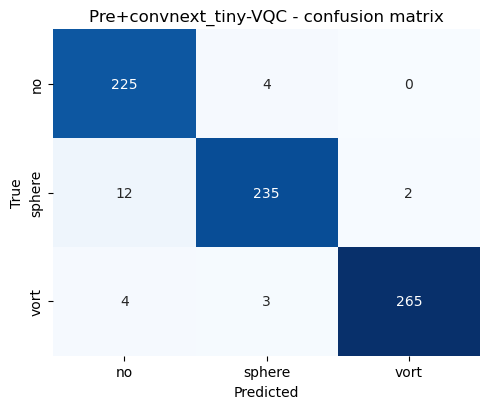

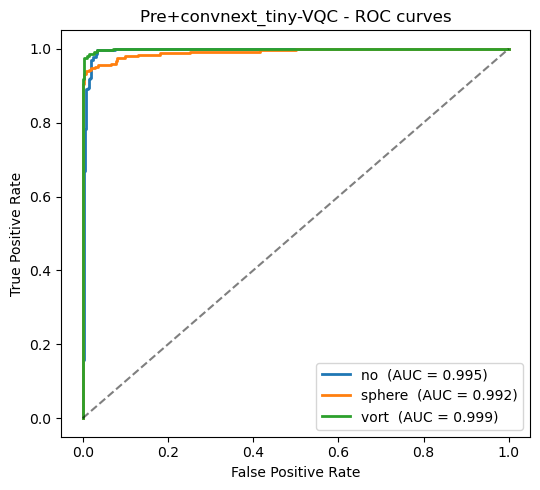

In [26]:


def plot_roc_curves(probs, y, class_names, title):
    n_cls = len(class_names)
    y_bin = label_binarize(y, classes=list(range(n_cls)))
    fig, ax = plt.subplots(figsize=(5.5, 5.0))
    for i, cname in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_bin[:, i], probs[:, i])
        ax.plot(fpr, tpr, lw=2, label=f"{cname}  (AUC = {auc(fpr, tpr):.3f})")
    ax.plot([0, 1], [0, 1], "k--", alpha=0.5)
    ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
    ax.set_title(title); ax.legend(loc="lower right")
    plt.tight_layout(); plt.show()


def evaluate_full(model, loader, class_names, tag: str):
    probs, preds, y = collect_predictions(model, loader, device)
    acc = accuracy_score(y, preds)
    y_bin = label_binarize(y, classes=list(range(len(class_names))))
    macro_auc = roc_auc_score(y_bin, probs, average="macro", multi_class="ovr")
    p, r, f1, _ = precision_recall_fscore_support(y, preds, average=None, zero_division=0)
    p_m, r_m, f1_m, _ = precision_recall_fscore_support(y, preds, average="macro", zero_division=0)
    cm = confusion_matrix(y, preds)
    print(f"\n=== {tag} ===")
    print(f"Test accuracy: {acc:.4f}")
    print(f"Macro ROC-AUC: {macro_auc:.4f}")
    print(f"Macro P/R/F1: {p_m:.4f} / {r_m:.4f} / {f1_m:.4f}")
    print(classification_report(y, preds, target_names=class_names, digits=4))
    plot_confusion(cm, class_names, title=f"{tag} - confusion matrix")
    plot_roc_curves(probs, y, class_names, title=f"{tag} - ROC curves")
    return {
        "tag": tag, "accuracy": acc, "macro_auc": macro_auc,
        "macro_precision": p_m, "macro_recall": r_m, "macro_f1": f1_m,
        "per_class_precision": dict(zip(class_names, p.tolist())),
        "per_class_recall":    dict(zip(class_names, r.tolist())),
        "per_class_f1":        dict(zip(class_names, f1.tolist())),
        "probs": probs, "preds": preds, "targets": y,
    }


pre_vqc_results = evaluate_full(
    pre_vqc_model, test_loader, CLASS_NAMES,
    tag=f"Pre+{CFG['backbone']}-VQC")

In [28]:


class ClassicalModel(nn.Module):
    """
    Pure-classical baseline:
        frontend (convnext_tiny + bridge MLP) -> Linear(n_qubits, n_classes) -> log_softmax

    Identical structure to Stage1Model except the sigmoid*pi/2 -> VQC block is dropped.
    The bridge output goes straight to the linear classifier.
    """
    def __init__(self, frontend: nn.Module, n_qubits: int, n_classes: int):
        super().__init__()
        self.frontend = frontend
        self.head = nn.Linear(n_qubits, n_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        feats = self.frontend(x)
        return F.log_softmax(self.head(feats), dim=1)


def build_classical_model(cfg: Dict[str, Any]) -> ClassicalModel:
    fe = get_frontend(cfg["backbone"], cfg["n_qubits"], pretrained=cfg["pretrained"])
    return ClassicalModel(fe, n_qubits=cfg["n_qubits"], n_classes=cfg["n_classes"])



_m = build_classical_model(CFG).to(device)
_xb = torch.randn(2, 3, CFG["resize_to"], CFG["resize_to"], device=device)
_yb = _m(_xb)
print(f"ClassicalModel out shape: {tuple(_yb.shape)} (expected (2, {CFG['n_classes']}))")
print(f"ClassicalModel params: {sum(p.numel() for p in _m.parameters()):,}")
print(f"  backbone : {sum(p.numel() for p in _m.frontend.backbone.parameters()):,}")
print(f"  bridge   : {sum(p.numel() for p in _m.frontend.bridge.parameters()):,}")
print(f"  head     : {sum(p.numel() for p in _m.head.parameters()):,}")
print("  vqc      : 0  (pure classical baseline)")
del _m, _xb, _yb

ClassicalModel out shape: (2, 3) (expected (2, 3))
ClassicalModel params: 28,061,475
  backbone : 27,820,128
  bridge   : 241,320
  head     : 27
  vqc      : 0  (pure classical baseline)


In [29]:


CLASSICAL_DIR = os.path.join(CKPT_ROOT, "classical")
os.makedirs(CLASSICAL_DIR, exist_ok=True)
CFG["classical_ckpt"] = os.path.join(CLASSICAL_DIR, f"{_safe_name(CFG['backbone'])}.pth")


def get_classical_param_groups(model: ClassicalModel, cfg: Dict[str, Any]) -> List[Dict[str, Any]]:
    return [
        {"params": list(model.frontend.backbone.parameters()),
         "lr": cfg["stage1_lr_backbone"], "name": "backbone"},
        {"params": list(model.frontend.bridge.parameters()) + list(model.head.parameters()),
         "lr": cfg["stage1_lr_bridge"], "name": "bridge+head"},
    ]


def run_classical(cfg, train_loader, val_loader, augmenter: Optional[nn.Module] = None):
    torch.manual_seed(cfg["seed"])
    model = build_classical_model(cfg).to(device)

    cw = cfg.get("class_weights")
    if cw is not None and any(w != 1.0 for w in cw):
        cw_t = torch.tensor(cw, dtype=torch.float32, device=device)
        criterion = nn.NLLLoss(weight=cw_t)
        print(f"[classical] using class weights {cw}")
    else:
        criterion = nn.NLLLoss()

    optimizer = optim.Adam(get_classical_param_groups(model, cfg), weight_decay=cfg["stage1_wd"])
    scheduler = LambdaLR(
        optimizer,
        lr_lambda=lambda e: warmup_cosine_factor(e, cfg["warmup_epochs"], cfg["stage1_epochs"]),
    )

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_acc, best_state = -1.0, None
    print(f"[classical] pure classical: {cfg['backbone']} frontend + Linear({cfg['n_qubits']} -> {cfg['n_classes']}) (NO VQC)")
    print(f"[classical] augmentation: {'ON' if augmenter is not None else 'OFF'}")
    print(f"[classical] trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

    for epoch in range(cfg["stage1_epochs"]):
        model.train()
        tr_loss = tr_correct = tr_total = 0
        pbar = tqdm(train_loader, desc=f"[classical] ep {epoch+1}/{cfg['stage1_epochs']}", leave=False)
        for xb, yb in pbar:
            xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
            if augmenter is not None and model.training:
                xb = augmenter(xb)
            optimizer.zero_grad(set_to_none=True)
            logp = model(xb)
            loss = criterion(logp, yb)
            loss.backward()
            if cfg.get("grad_clip"):
                torch.nn.utils.clip_grad_norm_(model.parameters(), cfg["grad_clip"])
            optimizer.step()
            tr_loss += loss.item() * xb.size(0)
            tr_correct += (logp.argmax(1) == yb).sum().item()
            tr_total += xb.size(0)
            pbar.set_postfix(loss=f"{loss.item():.4f}")
        train_loss, train_acc = tr_loss / tr_total, tr_correct / tr_total

        model.eval()
        v_loss = v_correct = v_total = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
                logp = model(xb)
                v_loss += criterion(logp, yb).item() * xb.size(0)
                v_correct += (logp.argmax(1) == yb).sum().item()
                v_total += xb.size(0)
        val_loss, val_acc = v_loss / v_total, v_correct / v_total

        for k, v in zip(["train_loss", "train_acc", "val_loss", "val_acc"],
                        [train_loss, train_acc, val_loss, val_acc]):
            history[k].append(v)

        is_best = val_acc > best_val_acc
        if is_best:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())
            torch.save(best_state, cfg["classical_ckpt"])

        scheduler.step()
        lrs = " ".join(f"{g['name']}={g['lr']:.1e}" for g in optimizer.param_groups)
        print(f"[classical] ep {epoch+1:02d}/{cfg['stage1_epochs']} | {lrs} | "
              f"train loss={train_loss:.4f} acc={train_acc:.4f} | "
              f"val loss={val_loss:.4f} acc={val_acc:.4f} {'*' if is_best else ''}")

    if best_state is not None:
        model.load_state_dict(best_state)
    print(f"\n[classical] Best val acc: {best_val_acc:.4f}")
    print(f"[classical] Saved best ckpt: {cfg['classical_ckpt']}")
    return model, history


t0 = time.time()
classical_model, classical_history = run_classical(
    CFG, train_loader, val_loader, augmenter=augmenter,
)
print(f"[classical] total time: {(time.time()-t0)/60:.1f} min")

[classical] using class weights [1.0, 2.5, 2.0]
[classical] pure classical: convnext_tiny frontend + Linear(8 -> 3) (NO VQC)
[classical] augmentation: ON
[classical] trainable params: 28,061,475


[classical] ep 1/40:   0%|          | 0/118 [00:00<?, ?it/s]

[classical] ep 01/40 | backbone=1.3e-05 bridge+head=1.3e-04 | train loss=1.0337 acc=0.3663 | val loss=0.9149 acc=0.4997 *


[classical] ep 2/40:   0%|          | 0/118 [00:00<?, ?it/s]

[classical] ep 02/40 | backbone=1.9e-05 bridge+head=1.9e-04 | train loss=0.9516 acc=0.4697 | val loss=0.8325 acc=0.6553 *


...

[classical] ep 38/40 | backbone=4.8e-07 bridge+head=4.8e-06 | train loss=0.1197 acc=0.9662 | val loss=0.1363 acc=0.9585 


[classical] ep 39/40:   0%|          | 0/118 [00:00<?, ?it/s]

[classical] ep 39/40 | backbone=1.2e-07 bridge+head=1.2e-06 | train loss=0.1176 acc=0.9675 | val loss=0.1360 acc=0.9609 *


[classical] ep 40/40:   0%|          | 0/118 [00:00<?, ?it/s]

[classical] ep 40/40 | backbone=0.0e+00 bridge+head=0.0e+00 | train loss=0.1169 acc=0.9672 | val loss=0.1354 acc=0.9604 

[classical] Best val acc: 0.9609
[classical] Saved best ckpt: ./checkpoints/classical/convnext_tiny.pth
[classical] total time: 28.1 min


eval:   0%|          | 0/3 [00:00<?, ?it/s]


=== Classical-convnext_tiny (no VQC) ===
Test accuracy: 0.9600
Macro ROC-AUC: 0.9951
Macro P/R/F1: 0.9595 / 0.9603 / 0.9597
              precision    recall  f1-score   support

          no     0.9451    0.9782    0.9614       229
      sphere     0.9628    0.9357    0.9491       249
        vort     0.9705    0.9669    0.9687       272

    accuracy                         0.9600       750
   macro avg     0.9595    0.9603    0.9597       750
weighted avg     0.9602    0.9600    0.9599       750



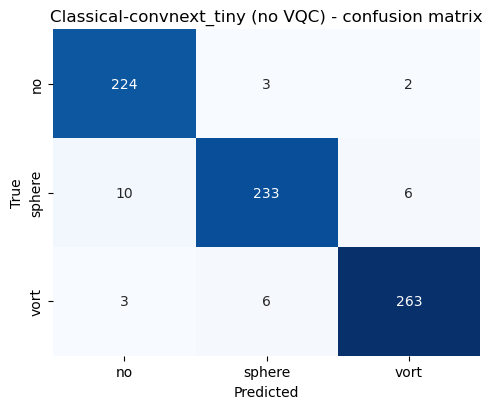

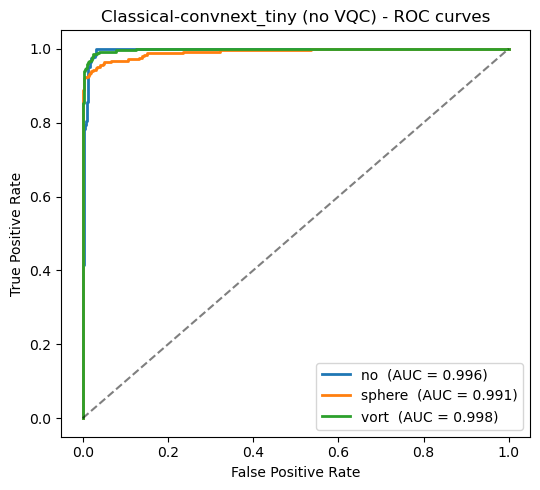

In [30]:


classical_results = evaluate_full(
    classical_model, test_loader, CLASS_NAMES,
    tag=f"Classical-{CFG['backbone']} (no VQC)",
)

=== Runs included ===
  + Pre+<Backbone>-VQC (Stage 1 -> Stage 2)
  + Pure classical <Backbone> (no VQC)
  + torchquantum_v10 (external reference)

=== Runs missing (skipped) ===
  - ImageNet-only-<Backbone>-VQC (no Stage 1) (run CELL 12 to add)

=== Comparison ===
                                      model  test_accuracy  macro_AUC  macro_precision  macro_recall  macro_F1
                      Pre+convnext_tiny-VQC         0.9667     0.9952           0.9657        0.9669    0.9660
           Classical-convnext_tiny (no VQC)         0.9600     0.9951           0.9595        0.9603    0.9597
torchquantum_v10 (ResNet18+VQC, no Stage 1)         0.9240     0.9837           0.9241        0.9243    0.9240

=== Quantum-vs-classical analysis ===
Pure classical     | acc=0.9600  AUC=0.9951
Pre+convnext_tiny-VQC | acc=0.9667  AUC=0.9952  (delta acc=+0.0067, delta AUC=+0.0000)

Verdict (Pre+VQC vs pure classical, on test acc): quantum BEATS classical by 0.67 %


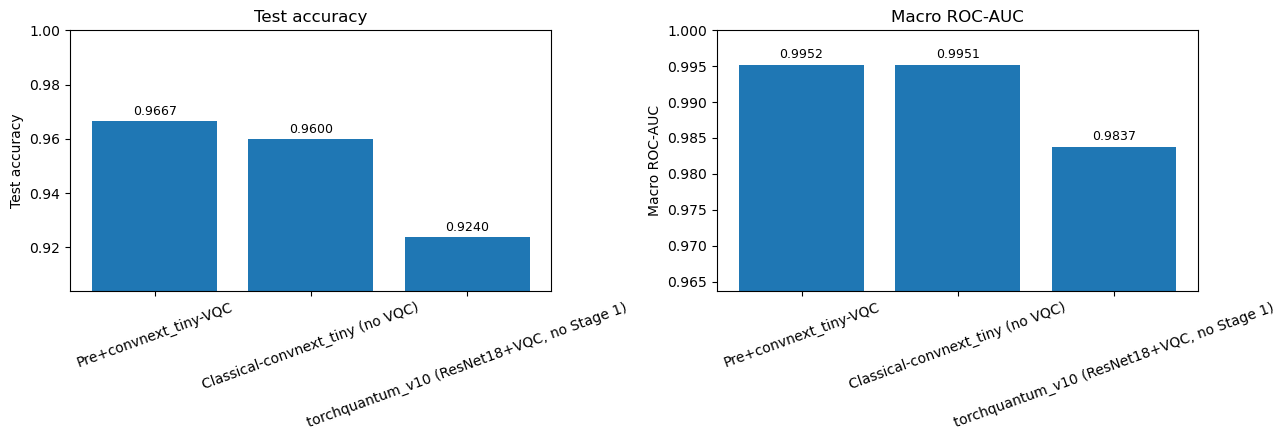

In [31]:


TORCHQUANTUM_V10_REF = {
    "tag": "torchquantum_v10 (ResNet18+VQC, no Stage 1)",
    "accuracy": 0.9240,
    "macro_auc": 0.9837,
    "macro_precision": 0.9241,
    "macro_recall": 0.9243,
    "macro_f1": 0.9240,
}


def _row(d):
    return {
        "model": d["tag"],
        "test_accuracy": d.get("accuracy"),
        "macro_AUC": d.get("macro_auc"),
        "macro_precision": d.get("macro_precision"),
        "macro_recall": d.get("macro_recall"),
        "macro_F1": d.get("macro_f1"),
    }


rows = []
present = []
missing = []

for varname, label in [
    ("pre_vqc_results", "Pre+<Backbone>-VQC (Stage 1 -> Stage 2)"),
    ("baseline_results", "ImageNet-only-<Backbone>-VQC (no Stage 1)"),
    ("classical_results", "Pure classical <Backbone> (no VQC)"),
]:
    if varname in globals():
        rows.append(_row(globals()[varname]))
        present.append(label)
    else:
        missing.append((varname, label))

rows.append(_row(TORCHQUANTUM_V10_REF))
present.append("torchquantum_v10 (external reference)")

comparison_df = pd.DataFrame(rows)
for c in ["test_accuracy", "macro_AUC", "macro_precision", "macro_recall", "macro_F1"]:
    comparison_df[c] = pd.to_numeric(comparison_df[c], errors="coerce")

print("=== Runs included ===")
for p in present:
    print(f"  + {p}")
if missing:
    print("\n=== Runs missing (skipped) ===")
    for varname, label in missing:
        cell_hint = {
            "pre_vqc_results": "CELL 11",
            "baseline_results": "CELL 12",
            "classical_results": "CELL 14+15",
        }[varname]
        print(f"  - {label} (run {cell_hint} to add)")

print("\n=== Comparison ===")
print(comparison_df.to_string(index=False, na_rep="-", float_format="%.4f"))

if "pre_vqc_results" in globals() and "classical_results" in globals():
    classical_acc = classical_results["accuracy"]
    pre_vqc_acc = pre_vqc_results["accuracy"]
    classical_auc = classical_results["macro_auc"]
    pre_vqc_auc = pre_vqc_results["macro_auc"]

    print("\n=== Quantum-vs-classical analysis ===")
    print(f"Pure classical     | acc={classical_acc:.4f}  AUC={classical_auc:.4f}")
    if "baseline_results" in globals():
        b_acc = baseline_results["accuracy"]
        b_auc = baseline_results["macro_auc"]
        print(f"ImageNet-only-VQC  | acc={b_acc:.4f}  AUC={b_auc:.4f}  "
              f"(delta acc={b_acc - classical_acc:+.4f}, delta AUC={b_auc - classical_auc:+.4f})")
    print(f"Pre+{CFG['backbone']}-VQC | acc={pre_vqc_acc:.4f}  AUC={pre_vqc_auc:.4f}  "
          f"(delta acc={pre_vqc_acc - classical_acc:+.4f}, delta AUC={pre_vqc_auc - classical_auc:+.4f})")

    verdict = ("BEATS" if pre_vqc_acc > classical_acc
               else "LOSES TO" if pre_vqc_acc < classical_acc else "TIES")
    print(f"\nVerdict (Pre+VQC vs pure classical, on test acc): "
          f"quantum {verdict} classical by {abs(pre_vqc_acc - classical_acc)*100:.2f} %")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
mask_acc = comparison_df["test_accuracy"].notna()
mask_auc = comparison_df["macro_AUC"].notna()

if mask_acc.any():
    sub = comparison_df.loc[mask_acc]
    axes[0].bar(sub["model"], sub["test_accuracy"])
    axes[0].set_ylabel("Test accuracy")
    axes[0].set_ylim(max(0.0, sub["test_accuracy"].min() - 0.02), 1.0)
    axes[0].set_title("Test accuracy")
    axes[0].tick_params(axis="x", rotation=20)
    for i, v in enumerate(sub["test_accuracy"]):
        axes[0].text(i, v + 0.002, f"{v:.4f}", ha="center", fontsize=9)

if mask_auc.any():
    sub = comparison_df.loc[mask_auc]
    axes[1].bar(sub["model"], sub["macro_AUC"])
    axes[1].set_ylabel("Macro ROC-AUC")
    axes[1].set_ylim(max(0.0, sub["macro_AUC"].min() - 0.02), 1.0)
    axes[1].set_title("Macro ROC-AUC")
    axes[1].tick_params(axis="x", rotation=20)
    for i, v in enumerate(sub["macro_AUC"]):
        axes[1].text(i, v + 0.001, f"{v:.4f}", ha="center", fontsize=9)

plt.tight_layout(); plt.show()